In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pysam import AlignmentFile
import pysam
from scipy.signal import savgol_filter
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import json

from cuban_lib.visualize import plot_breakpoints_ill_pb, plot_breakpoints_ill
from cuban_lib.utils import compute_baseline_cov

plt.style.use('ggplot')

In [2]:
# Load repeat annotations
repeats = '/confidential/tGenVar/ref/hg38/annotation/hg38_repeatmasker.tsv'
repeat_df = pd.read_csv(repeats, sep='\t')

In [3]:
# Region
sv_type = 'DEL'
chrom = 'chr5'
start = 139322504
stop = start + 50

# Samples from cohort
cohort_samples = {'16-110' : {'family_status' : 'index',
                              'disease_status' : 'affected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-110/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30},
                  '16-112' : {'family_status' : 'father',
                              'disease_status' : 'unaffected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-112/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30},
                  '16-113' : {'family_status' : 'mother',
                              'disease_status' : 'unaffected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-113/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30}}

# Load baseline coverage for control samples
with open('resources/baseline_cov_ill.json', 'r') as f:
    baseline_cov_ill = json.load(f)
with open('resources/baseline_cov_pb.json', 'r') as f:
    baseline_cov_pb = json.load(f)

# Samples from control
control_samples = {'HG002 - Illumina' : {'family_status' : 'control',
                                         'disease_status' : 'unaffected',
                                         'technology' : 'ill',
                                         'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/ill/bam/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                                         'baseline_cov' : baseline_cov_ill[chrom]},
                   'HG002 - PacBio HiFi' : {'family_status' : 'control',
                                            'disease_status' : 'unaffected',
                                            'technology' : 'pb',
                                            'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/pb_hifi/bam/HG002_GRCh38.haplotag.10x.bam',
                                            'baseline_cov' : baseline_cov_pb[chrom]}}

samples = {**cohort_samples, **control_samples}

In [4]:
rep_y_pos_map = {'LINE' : (-6, '#6ac0b7'),
                 'SINE' : (-14, '#b7954b'),
                 'LTR' : (-22, '#f0b6a0'),
                 'DNA' : (-30, '#5066a2'),
                 'Simple_repeat' : (-38, '#504669'),
                 'Satellite' : (-46, '#df624c'),
                 'Low_complexity' : (-54, '#61856b'),
                 'Retroposon' : (-62, '#2f7155')}

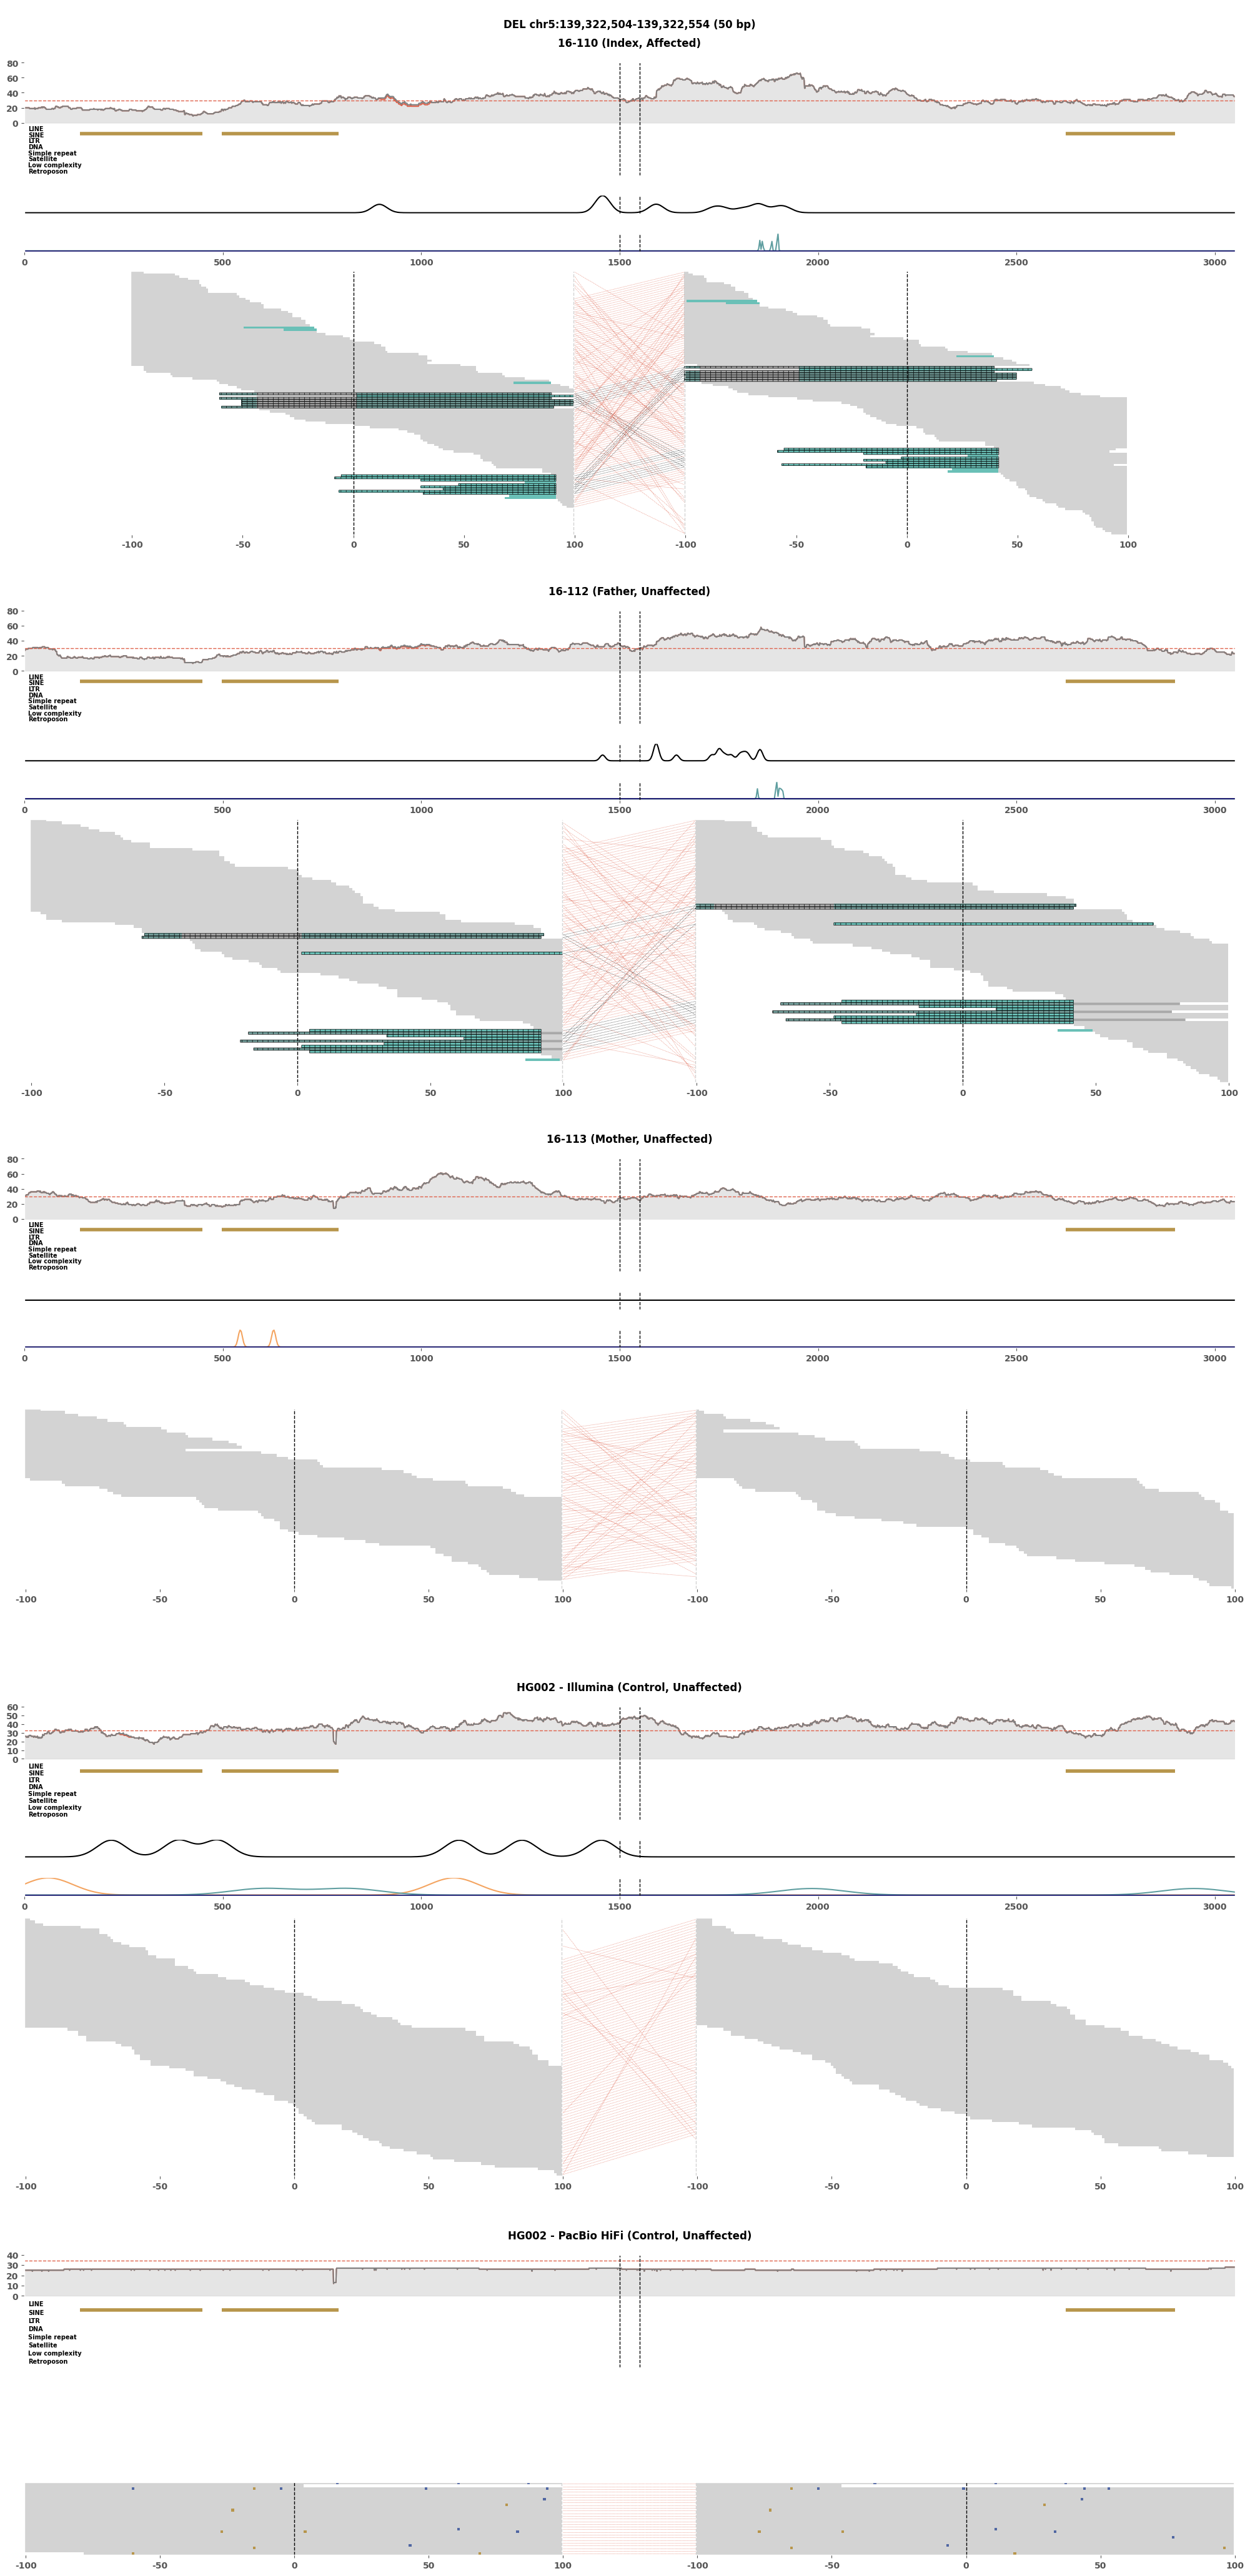

In [5]:
plot_breakpoints_ill(samples, repeat_df, sv_type, chrom, start, stop, padding=1500, window=100, collapse_ins=False)